Device        : cuda
Seeds         : [42, 123, 256, 789, 999]
Context       : 7 (window=15)
SupCon λ=0.2, τ=0.05
Output        : D:\22\AA\evaluation\dualBranch_spectrogram_supcon_c7
Split loaded -> Train:76  Test:20
TEST_SUBS: ['sub-121', 'sub-081', 'sub-038', 'sub-035', 'sub-104', 'sub-112', 'sub-007', 'sub-068', 'sub-093', 'sub-014', 'sub-087', 'sub-105', 'sub-017', 'sub-023', 'sub-036', 'sub-040', 'sub-045', 'sub-005', 'sub-019', 'sub-100']

Building datasets (once for all seeds)...
  Samples  : 71,347
  RAM      : 2.57 GB
  No TSV   : 0 subjects
  Weight distribution:
    w=1.0 :  59,303 (83.1%)
    w=0.4 :     930 (1.3%)
    w=0.2 :   7,686 (10.8%)
    w=0.1 :   3,385 (4.7%)
    w=0.0 :      43 (0.1%)

  Samples  : 19,763
  RAM      : 0.71 GB
  No TSV   : 0 subjects
  Weight distribution:
    w=1.0 :  15,258 (77.2%)
    w=0.4 :     428 (2.2%)
    w=0.2 :   3,306 (16.7%)
    w=0.1 :     771 (3.9%)
Datasets ready.

Class weights:
  Wake: 1.844
  N1: 3.142
  N2: 0.442
  N3: 1.016
  R

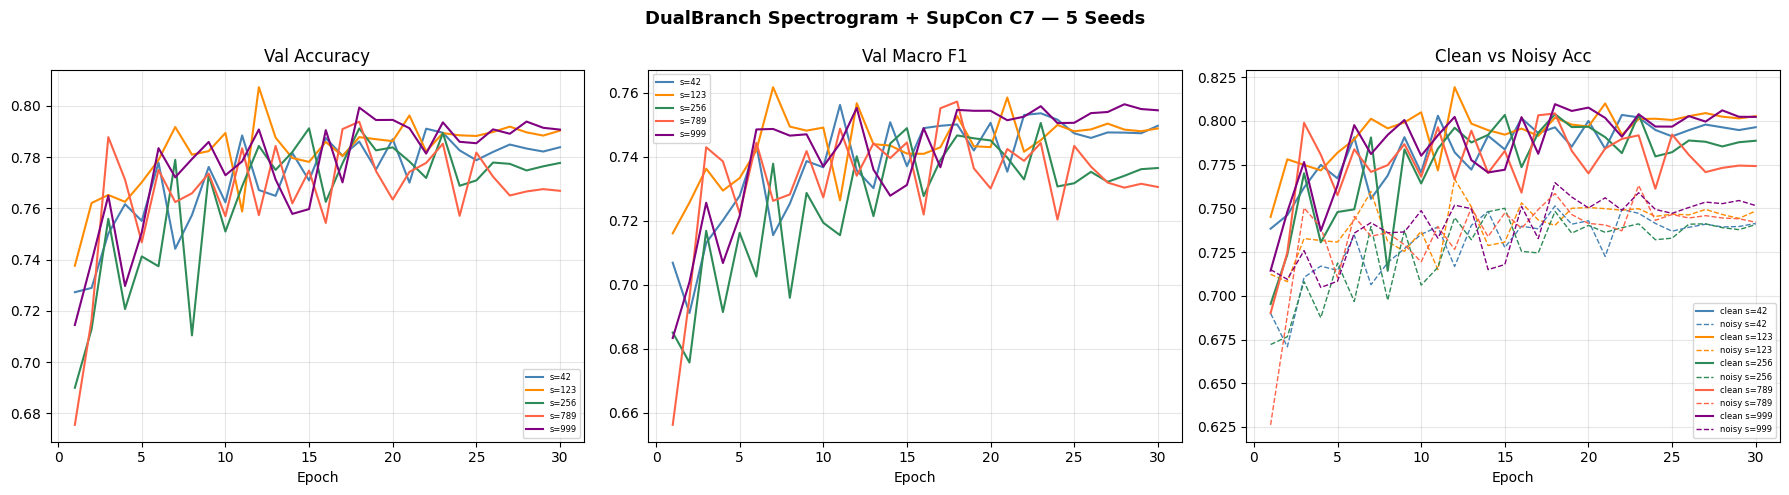

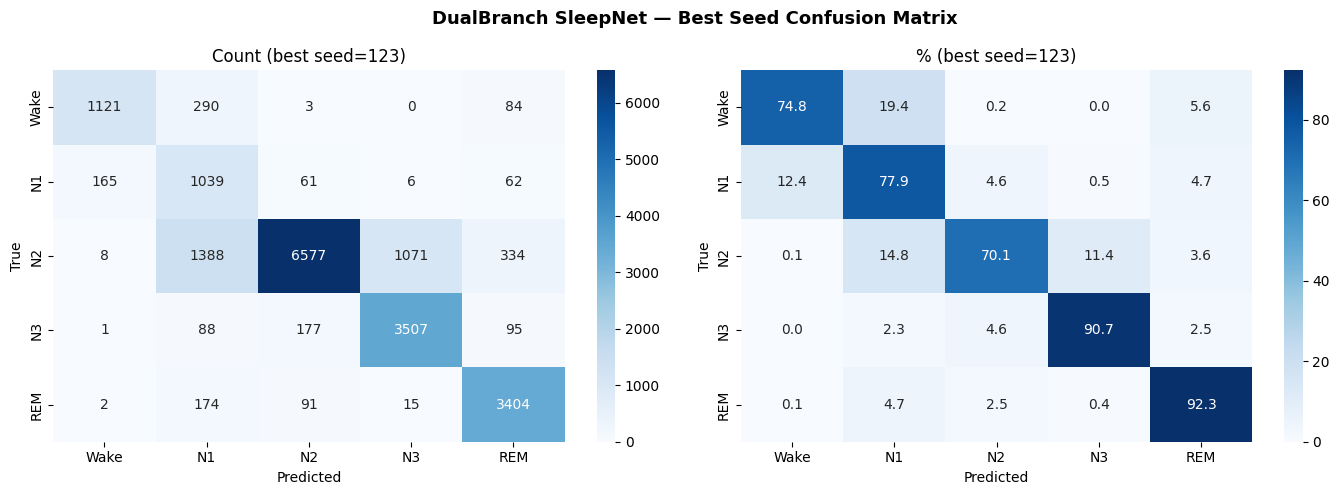

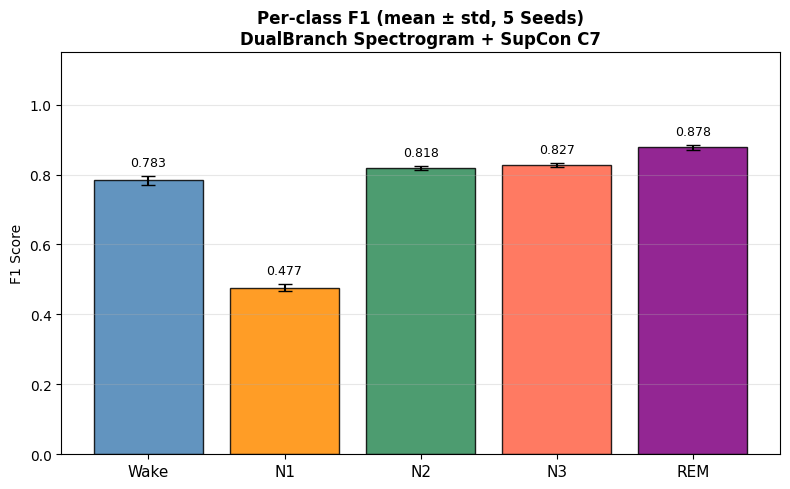


All outputs saved: D:\22\AA\evaluation\dualBranch_spectrogram_supcon_c7
Done!


In [2]:
# ============================================================
# Dual-Branch Spectrogram + Multi-Scale CNN + SupCon Loss
# Context=7, Artifact-Aware
#
# Architecture changes from previous best (C7 + SupCon λ=0.2):
#   1. Dual-Branch Epoch Encoder:
#      Branch A — Multi-Scale Time CNN (3 parallel kernels)
#      Branch B — Spectrogram 2D CNN (STFT-based)
#      → Concatenate → project to d_model
#   2. Same Intra/Inter Transformer as before
#   3. Same SupCon Loss (λ=0.2, τ=0.05)
#   4. Same Artifact Weighting
#   5. Same Fixed Split
#
# Why this should help:
#   - Branch A: multi-scale kernel captures slow wave + transient
#   - Branch B: STFT spectrogram makes N1 alpha→theta visible
#   - Together: richer feature → better N1 discrimination
#
# Paper references:
#   - MultiScaleSleepNet (Liu et al., 2025, SJTU)
#   - WASR (Computers in Biology and Medicine, 2024)
#   - EEGSNet (PMC, 2022)
#   - SupCon (Khosla et al., NeurIPS 2020)
# ============================================================

import os
import csv
import math
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================
# PATHS & CONFIG
# ============================================================
SAVE_PATH     = r"D:\22\AA\preprocess\preprocessed_FFinal"
ARTIFACT_PATH = r"D:\22\thesis 3233\Wearanize+_PlugNPlay_v1.0\Wearanize+_PlugNPlay_v1.0\derivatives\eegfloss-v1.0"
EVAL_PATH     = r"D:\22\AA\evaluation\dualBranch_spectrogram_supcon_c7"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 7
WINDOW      = 2 * CONTEXT + 1       # 15
N_EPOCHS    = 30
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]

# Model
D_MODEL     = 128
NHEAD       = 8
NUM_LAYERS  = 3
DIM_FF      = 256
DROPOUT     = 0.4

# SupCon
SUPCON_LAMBDA = 0.2
SUPCON_TEMP   = 0.05
PROJ_DIM      = 64

# Spectrogram config
# STFT on 30s @ 100Hz = 3000 samples
# n_fft=256 → freq bins=129, hop=32 → time frames~94
STFT_N_FFT  = 256
STFT_HOP    = 32
STFT_WIN    = 256
# Frequency range to keep: 0.5–30 Hz (sleep-relevant)
# @ 100Hz sampling, freq resolution = 100/256 = 0.39 Hz/bin
# bin 1 (~0.39Hz) to bin 77 (~30Hz)
SPEC_FREQ_LOW  = 1    # bin index
SPEC_FREQ_HIGH = 78   # bin index  → 77 freq bins
SPEC_FREQ_BINS = SPEC_FREQ_HIGH - SPEC_FREQ_LOW  # 77

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {device}")
print(f"Seeds         : {SEEDS}")
print(f"Context       : {CONTEXT} (window={WINDOW})")
print(f"SupCon λ={SUPCON_LAMBDA}, τ={SUPCON_TEMP}")
print(f"Output        : {EVAL_PATH}")

# ============================================================
# ARTIFACT WEIGHT CONFIG
# ============================================================
ARTIFACT_WEIGHT_MAP = {0: 1.0, 1: 0.0, 2: 0.4, 3: 0.2, 4: 0.1}
TARGET_CHANNELS     = ["PSG_F3:A2", "PSG_C3:A2"]
FALLBACK_CHANNELS   = ["PSG_F3", "PSG_C3", "Zmax_EEGL", "Zmax_EEGR"]


# ============================================================
# ARTIFACT WEIGHT LOADER
# ============================================================
def load_artifact_weights(subject_id, artifact_path, epoch_duration=30):
    tsv_path = os.path.join(
        artifact_path, subject_id, "eeg",
        f"{subject_id}_task-sleep_proc-artifacts.tsv"
    )
    if not os.path.exists(tsv_path):
        return None
    try:
        df = pd.read_csv(tsv_path, sep='\t')
    except Exception:
        return None

    available = [ch for ch in TARGET_CHANNELS if ch in df.columns]
    if not available:
        available = [ch for ch in FALLBACK_CHANNELS if ch in df.columns]
    if not available:
        return None

    df['worst_score'] = df[available].max(axis=1).astype(int)
    df['sleep_epoch'] = ((df['offset'] - 1e-6) // epoch_duration).astype(int)
    epoch_scores = df.groupby('sleep_epoch')['worst_score'].max()

    n_ep    = int(epoch_scores.index.max()) + 1
    weights = np.ones(n_ep, dtype=np.float32)
    for ep_idx, score in epoch_scores.items():
        weights[int(ep_idx)] = ARTIFACT_WEIGHT_MAP.get(int(score), 1.0)
    return weights


# ============================================================
# FIXED SPLIT
# ============================================================
all_subjects = sorted([
    f.replace(".npz", "")
    for f in os.listdir(SAVE_PATH)
    if f.endswith(".npz") and not f.startswith("_")
])

_train_path = os.path.join(SAVE_PATH, "_train_subs.npy")
_test_path  = os.path.join(SAVE_PATH, "_test_subs.npy")

if os.path.exists(_train_path) and os.path.exists(_test_path):
    TRAIN_SUBS = np.load(_train_path, allow_pickle=True).tolist()
    TEST_SUBS  = np.load(_test_path,  allow_pickle=True).tolist()
    print(f"Split loaded -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")
else:
    _subs = all_subjects.copy()
    random.seed(42)
    random.shuffle(_subs)
    n          = int(0.8 * len(_subs))
    TRAIN_SUBS = _subs[:n]
    TEST_SUBS  = _subs[n:]
    np.save(_train_path, np.array(TRAIN_SUBS))
    np.save(_test_path,  np.array(TEST_SUBS))
    print(f"Split created -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")

print(f"TEST_SUBS: {TEST_SUBS}")


# ============================================================
# STFT SPECTROGRAM HELPER
# ============================================================
def compute_spectrogram_batch(x_window):
    """
    x_window : (B, W, C, T)  — raw time-domain signal
    Returns  : (B, W, C, F, T_spec) — log-magnitude spectrogram
    
    Only uses EEG channels (first 2) for spectrogram.
    F = SPEC_FREQ_BINS (77), T_spec = ~94 frames
    """
    B, W, C, T = x_window.shape
    # Use only EEG ch (0,1), not EOG
    eeg = x_window[:, :, :2, :]   # (B, W, 2, T)

    # Reshape for torch.stft: (B*W*2, T)
    sig = eeg.reshape(-1, T)

    window_fn = torch.hann_window(STFT_WIN, device=sig.device)

    # stft output: (B*W*2, F, T_spec, 2)  [real, imag]
    stft_out = torch.stft(
        sig,
        n_fft=STFT_N_FFT,
        hop_length=STFT_HOP,
        win_length=STFT_WIN,
        window=window_fn,
        return_complex=True
    )  # (B*W*2, F, T_spec)

    # Magnitude → log
    mag = stft_out.abs() + 1e-8
    log_mag = torch.log(mag)   # (B*W*2, F, T_spec)

    # Keep sleep-relevant frequencies only
    log_mag = log_mag[:, SPEC_FREQ_LOW:SPEC_FREQ_HIGH, :]
    # → (B*W*2, 77, T_spec)

    T_spec = log_mag.shape[-1]
    # Reshape back: (B, W, 2, 77, T_spec)
    log_mag = log_mag.reshape(B, W, 2, SPEC_FREQ_BINS, T_spec)

    return log_mag   # (B, W, 2, 77, T_spec)


# ============================================================
# DATASET
# ============================================================
class ArtifactAwareDataset(Dataset):
    def __init__(self, subject_list, data_path,
                 artifact_path, context=CONTEXT):
        self.context = context
        self.data    = []
        self.index   = []

        label_counter  = Counter()
        weight_counter = Counter()
        no_tsv_count   = 0

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                eeg    = d['eeg'][:, [0, 1], :]
                eog    = d['eog'][:, [0],    :]
                signal = np.concatenate([eeg, eog], axis=1).astype(np.float32)
                labels = d['labels'].copy()

            n = len(labels)
            art_w = load_artifact_weights(sub, artifact_path)
            if art_w is None:
                art_w        = np.ones(n, dtype=np.float32)
                no_tsv_count += 1
            else:
                if len(art_w) >= n:
                    art_w = art_w[:n]
                else:
                    pad   = np.ones(n - len(art_w), dtype=np.float32)
                    art_w = np.concatenate([art_w, pad])

            sub_idx = len(self.data)
            self.data.append((signal, labels))

            for i in range(n):
                w = float(art_w[i])
                self.index.append((sub_idx, i, n, w))
                label_counter[int(labels[i])] += 1
                weight_counter[round(w, 1)]   += 1

        self.label_counts = np.array(
            [label_counter[i] for i in range(5)], dtype=np.float32
        )

        total = len(self.index)
        ram   = sum(s.nbytes for s, _ in self.data) / 1e9
        print(f"  Samples  : {total:,}")
        print(f"  RAM      : {ram:.2f} GB")
        print(f"  No TSV   : {no_tsv_count} subjects")
        print(f"  Weight distribution:")
        for w in sorted(weight_counter.keys(), reverse=True):
            pct = weight_counter[w] / total * 100
            print(f"    w={w:.1f} : {weight_counter[w]:>7,} ({pct:.1f}%)")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n, weight = self.index[idx]
        signal, labels = self.data[sub_idx]

        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(signal[ei])

        x = np.stack(window_epochs, axis=0)   # (W, 3, 3000)
        y = int(labels[center_i])

        return (
            torch.FloatTensor(x),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float32)
        )


# ============================================================
# BUILD DATASETS
# ============================================================
print("\nBuilding datasets (once for all seeds)...")
train_ds = ArtifactAwareDataset(TRAIN_SUBS, SAVE_PATH, ARTIFACT_PATH)
print()
test_ds  = ArtifactAwareDataset(TEST_SUBS,  SAVE_PATH, ARTIFACT_PATH)
print("Datasets ready.")


# ============================================================
# POSITIONAL ENCODING
# ============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


# ============================================================
# BRANCH A — Multi-Scale Time Domain CNN
#
# 3 parallel conv paths with different kernel sizes:
#   Large kernel  (k=100): slow wave, delta/theta (~2-3 sec)
#   Medium kernel (k=50) : mid-range features
#   Small kernel  (k=25) : transient spike, spindle onset
# → concat → project to d_model//2
# ============================================================
class MultiScaleTimeCNN(nn.Module):
    def __init__(self, in_ch=3, out_dim=64, dropout=0.4):
        super().__init__()
        mid = 32

        # Large kernel — slow wave
        self.path_large = nn.Sequential(
            nn.Conv1d(in_ch, mid, kernel_size=100, stride=6, padding=50),
            nn.BatchNorm1d(mid), nn.GELU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(mid, mid, kernel_size=8, padding=4),
            nn.BatchNorm1d(mid), nn.GELU(),
            nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )
        # Medium kernel — baseline
        self.path_mid = nn.Sequential(
            nn.Conv1d(in_ch, mid, kernel_size=50, stride=6, padding=25),
            nn.BatchNorm1d(mid), nn.GELU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(mid, mid, kernel_size=8, padding=4),
            nn.BatchNorm1d(mid), nn.GELU(),
            nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )
        # Small kernel — transient
        self.path_small = nn.Sequential(
            nn.Conv1d(in_ch, mid, kernel_size=25, stride=6, padding=12),
            nn.BatchNorm1d(mid), nn.GELU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(mid, mid, kernel_size=8, padding=4),
            nn.BatchNorm1d(mid), nn.GELU(),
            nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )

        # Compute output seq length
        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, 3000)
            L_l = self.path_large(dummy).shape[2]
            L_m = self.path_mid(dummy).shape[2]
            L_s = self.path_small(dummy).shape[2]

        self.L_l = L_l
        self.L_m = L_m
        self.L_s = L_s

        # Adaptive pool to same length before concat
        self.pool_l = nn.AdaptiveAvgPool1d(L_m)
        self.pool_s = nn.AdaptiveAvgPool1d(L_m)

        # Project 3*mid → out_dim
        self.proj = nn.Sequential(
            nn.Conv1d(3 * mid, out_dim, kernel_size=1),
            nn.BatchNorm1d(out_dim), nn.GELU(),
        )
        self.out_len = L_m

    def forward(self, x):
        # x: (B, C, T)
        f_l = self.path_large(x)           # (B, 32, L_l)
        f_m = self.path_mid(x)             # (B, 32, L_m)
        f_s = self.path_small(x)           # (B, 32, L_s)

        f_l = self.pool_l(f_l)             # (B, 32, L_m)
        f_s = self.pool_s(f_s)             # (B, 32, L_m)

        f = torch.cat([f_l, f_m, f_s], dim=1)   # (B, 96, L_m)
        f = self.proj(f)                          # (B, out_dim, L_m)
        return f   # (B, out_dim, L_m)


# ============================================================
# BRANCH B — Spectrogram 2D CNN
#
# Input: log-magnitude STFT (2 EEG channels)
# Shape: (B, 2, 77, T_spec)
# → 2D CNN → global avg pool → FC → out_dim
#
# Captures alpha→theta transition for N1
# ============================================================
class SpectrogramCNN(nn.Module):
    def __init__(self, in_ch=2, out_dim=64, dropout=0.4):
        super().__init__()

        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv2d(in_ch, 32, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(32), nn.GELU(),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)),

            # Block 3
            nn.Conv2d(64, out_dim, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(out_dim), nn.GELU(),
            nn.Dropout2d(dropout),
        )

        # Global average pool → (B, out_dim, 1, 1) → (B, out_dim)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        # x: (B, 2, 77, T_spec)
        f = self.cnn(x)         # (B, out_dim, H', W')
        f = self.gap(f)         # (B, out_dim, 1, 1)
        f = f.squeeze(-1).squeeze(-1)  # (B, out_dim)
        return f   # (B, out_dim)


# ============================================================
# DUAL-BRANCH EPOCH ENCODER
#
# Combines Branch A (time) + Branch B (spectrogram)
# → concatenate → linear → d_model
# ============================================================
class DualBranchEpochEncoder(nn.Module):
    def __init__(self, in_ch=3, d_model=D_MODEL,
                 branch_dim=64, dropout=DROPOUT):
        super().__init__()
        self.d_model = d_model

        # Branch A: multi-scale time CNN
        self.branch_time = MultiScaleTimeCNN(
            in_ch=in_ch, out_dim=branch_dim, dropout=dropout
        )
        self.time_seq_len = self.branch_time.out_len

        # Branch B: spectrogram 2D CNN
        self.branch_spec = SpectrogramCNN(
            in_ch=2, out_dim=branch_dim, dropout=dropout
        )

        # Intra-epoch transformer on time branch features
        self.intra_pos = PositionalEncoding(
            branch_dim, max_len=self.time_seq_len + 10, dropout=dropout
        )
        self.intra_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=branch_dim, nhead=4,
                dim_feedforward=branch_dim * 2, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=1
        )

        # Fusion: time_pooled (branch_dim) + spec (branch_dim) → d_model
        self.fusion = nn.Sequential(
            nn.Linear(branch_dim * 2, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x_time, x_spec):
        """
        x_time : (B*W, C, T)      — raw signal
        x_spec : (B*W, 2, F, Ts)  — log spectrogram (EEG only)
        Returns: (B*W, d_model)
        """
        # --- Branch A ---
        f_time = self.branch_time(x_time)        # (B*W, branch_dim, L)
        f_time = f_time.permute(0, 2, 1)         # (B*W, L, branch_dim)
        f_time = self.intra_transformer(
            self.intra_pos(f_time)
        )                                         # (B*W, L, branch_dim)
        f_time = f_time.mean(dim=1)               # (B*W, branch_dim)

        # --- Branch B ---
        f_spec = self.branch_spec(x_spec)         # (B*W, branch_dim)

        # --- Fusion ---
        f = torch.cat([f_time, f_spec], dim=1)    # (B*W, 2*branch_dim)
        f = self.fusion(f)                         # (B*W, d_model)

        return f


# ============================================================
# FULL MODEL — DualBranch + Inter-Transformer + SupCon
# ============================================================
class DualBranchSleepNet(nn.Module):
    def __init__(
        self, in_ch=3, d_model=D_MODEL, nhead=NHEAD,
        num_layers=NUM_LAYERS, dim_ff=DIM_FF, dropout=DROPOUT,
        n_classes=5, context=CONTEXT,
        branch_dim=64, proj_dim=PROJ_DIM
    ):
        super().__init__()
        self.context = context
        self.d_model  = d_model

        # Dual-branch epoch encoder
        self.epoch_encoder = DualBranchEpochEncoder(
            in_ch=in_ch, d_model=d_model,
            branch_dim=branch_dim, dropout=dropout
        )

        # Inter-epoch transformer
        self.inter_pos = PositionalEncoding(
            d_model, max_len=WINDOW + 2, dropout=dropout
        )
        self.inter_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=num_layers
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

        # SupCon projection head
        self.projector = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, proj_dim),
        )

    def forward(self, x):
        """
        x: (B, W, C, T)
        """
        B, W, C, T = x.shape

        # Compute spectrogram on GPU for all window epochs
        # x_spec: (B, W, 2, F, Ts)
        x_spec = compute_spectrogram_batch(x)

        # Reshape for epoch encoder
        x_time = x.reshape(B * W, C, T)              # (B*W, C, T)
        x_spec_flat = x_spec.reshape(
            B * W, 2, SPEC_FREQ_BINS, x_spec.shape[-1]
        )                                              # (B*W, 2, F, Ts)

        # Epoch encoding → (B*W, d_model)
        epoch_feat = self.epoch_encoder(x_time, x_spec_flat)

        # Reshape to sequence: (B, W, d_model)
        epoch_feat = epoch_feat.view(B, W, self.d_model)

        # Inter-epoch transformer
        ctx_feat = self.inter_transformer(
            self.inter_pos(epoch_feat)
        )                                              # (B, W, d_model)

        # Center epoch
        center = ctx_feat[:, self.context, :]          # (B, d_model)

        logits = self.classifier(center)
        proj   = F.normalize(self.projector(center), dim=1)

        return logits, proj


# ============================================================
# SUPERVISED CONTRASTIVE LOSS
# ============================================================
class SupConLoss(nn.Module):
    def __init__(self, temperature=SUPCON_TEMP, mask_n1_only=False):
        super().__init__()
        self.temperature  = temperature
        self.mask_n1_only = mask_n1_only

    def forward(self, features, labels):
        B      = features.shape[0]
        device = features.device

        sim     = torch.matmul(features, features.T) / self.temperature
        sim_max, _ = torch.max(sim, dim=1, keepdim=True)
        sim     = sim - sim_max.detach()

        labels_row = labels.unsqueeze(1)
        labels_col = labels.unsqueeze(0)
        pos_mask   = (labels_row == labels_col).float()
        self_mask  = torch.eye(B, device=device)
        pos_mask   = pos_mask - self_mask

        denom_mask = 1 - self_mask
        exp_sim    = torch.exp(sim) * denom_mask
        log_prob   = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)

        n_pos = pos_mask.sum(dim=1)

        if self.mask_n1_only:
            anchor_mask = (labels == 1).float()
        else:
            anchor_mask = (n_pos > 0).float()

        loss_per = -(pos_mask * log_prob).sum(dim=1) / (n_pos + 1e-8)
        loss = (loss_per * anchor_mask).sum() / (anchor_mask.sum() + 1e-8)
        return loss


supcon_criterion = SupConLoss(temperature=SUPCON_TEMP, mask_n1_only=False)


# ============================================================
# LOSS FUNCTIONS
# ============================================================
def artifact_weighted_ce(logits, labels, weights, class_weights):
    ce   = nn.CrossEntropyLoss(weight=class_weights, reduction='none')(logits, labels)
    w_ce = ce * weights
    valid = weights > 0
    if valid.sum() == 0:
        return w_ce.mean()
    return w_ce[valid].mean()


def combined_loss(logits, proj, labels, weights, class_weights):
    l_ce     = artifact_weighted_ce(logits, labels, weights, class_weights)
    l_supcon = supcon_criterion(proj, labels)
    total    = l_ce + SUPCON_LAMBDA * l_supcon
    return total, l_ce.item(), l_supcon.item()


# ============================================================
# CLASS WEIGHTS
# ============================================================
cw_np = train_ds.label_counts.sum() / (5 * train_ds.label_counts)
cw    = torch.FloatTensor(cw_np).to(device)
print(f"\nClass weights:")
for name, w in zip(LABEL_NAMES, cw_np):
    print(f"  {name}: {w:.3f}")


# ============================================================
# HELPERS
# ============================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


# ============================================================
# TRAIN FUNCTION
# ============================================================
def train_epoch_fn(model, loader, optimizer, scheduler):
    model.train()
    total_loss = total_ce = total_sc = 0
    preds, labs = [], []

    for i, (x, y, w) in enumerate(loader):
        x, y, w = x.to(device), y.to(device), w.to(device)
        optimizer.zero_grad()

        logits, proj = model(x)
        loss, l_ce, l_sc = combined_loss(logits, proj, y, w, cw)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        total_ce   += l_ce
        total_sc   += l_sc
        preds.extend(logits.argmax(1).cpu().numpy())
        labs.extend(y.cpu().numpy())

        if (i + 1) % 300 == 0:
            print(f"  batch {i+1}/{len(loader)}", end="\r")

    n   = len(loader)
    acc = accuracy_score(labs, preds)
    f1  = f1_score(labs, preds, average='macro', zero_division=0)
    return total_loss / n, total_ce / n, total_sc / n, acc, f1


# ============================================================
# EVAL FUNCTION
# ============================================================
def evaluate_fn(model, loader):
    model.eval()
    preds, labs, weights_all = [], [], []

    with torch.no_grad():
        for x, y, w in loader:
            logits, _ = model(x.to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
            labs.extend(y.numpy())
            weights_all.extend(w.numpy())

    preds       = np.array(preds)
    labs        = np.array(labs)
    weights_all = np.array(weights_all)

    acc     = accuracy_score(labs, preds)
    f1      = f1_score(labs, preds, average='macro', zero_division=0)
    kappa   = cohen_kappa_score(labs, preds)
    per_cls = f1_score(labs, preds, average=None, zero_division=0)

    clean_mask = weights_all == 1.0
    noisy_mask = (weights_all > 0) & (weights_all < 1.0)
    clean_acc  = accuracy_score(labs[clean_mask], preds[clean_mask]) if clean_mask.sum() > 0 else 0.0
    noisy_acc  = accuracy_score(labs[noisy_mask], preds[noisy_mask]) if noisy_mask.sum() > 0 else 0.0

    return (acc, f1, kappa, per_cls, preds, labs,
            clean_acc, noisy_acc,
            int(clean_mask.sum()), int(noisy_mask.sum()))


# ============================================================
# CSV SETUP
# ============================================================
csv_epoch_path = os.path.join(EVAL_PATH, "all_seeds_epoch_log.csv")
with open(csv_epoch_path, 'w', newline='') as f:
    csv.writer(f).writerow([
        'seed', 'epoch',
        'tr_loss', 'tr_ce', 'tr_supcon', 'tr_acc', 'tr_f1',
        'vl_acc', 'vl_f1', 'vl_kappa', 'clean_acc', 'noisy_acc'
    ])

csv_summary_path = os.path.join(EVAL_PATH, "summary.csv")
fields = ["seed", "acc", "f1_macro", "kappa",
          "f1_Wake", "f1_N1", "f1_N2", "f1_N3", "f1_REM",
          "clean_acc", "noisy_acc"]
with open(csv_summary_path, 'w', newline='') as f:
    csv.DictWriter(f, fields).writeheader()


# ============================================================
# 5-SEED TRAINING LOOP
# ============================================================
all_seed_results = []
all_cms          = []

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}")
    print(f"SEED {seed}  ({seed_idx + 1}/{len(SEEDS)})")
    print(f"{'='*60}")

    set_seed(seed)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=0,
        generator=torch.Generator().manual_seed(seed)
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=0
    )

    model    = DualBranchSleepNet(in_ch=3).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Total Parameters : {n_params:,}")

    optimizer   = optim.AdamW(
        model.parameters(),
        lr=5e-4, weight_decay=3e-4,
        betas=(0.9, 0.98), eps=1e-9
    )
    total_steps  = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def warmup_cosine(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=warmup_cosine
    )

    best_f1   = 0.0
    best_path = os.path.join(EVAL_PATH, f"best_seed{seed}.pt")
    history   = []

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_ce, tr_sc, tr_acc, tr_f1 = train_epoch_fn(
            model, train_loader, optimizer, scheduler
        )
        (vl_acc, vl_f1, vl_kap, vl_per,
         _, _, clean_acc, noisy_acc,
         n_clean, n_noisy) = evaluate_fn(model, test_loader)

        saved = ""
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), best_path)
            saved = " <- BEST"

        lr = optimizer.param_groups[0]['lr']
        history.append({
            'epoch':     epoch,
            'tr_loss':   tr_loss, 'tr_ce':    tr_ce,   'tr_sc': tr_sc,
            'tr_acc':    tr_acc,  'tr_f1':    tr_f1,
            'vl_acc':    vl_acc,  'vl_f1':    vl_f1,   'vl_kap': vl_kap,
            'clean_acc': clean_acc, 'noisy_acc': noisy_acc
        })

        print(
            f"  Ep[{epoch:02d}/{N_EPOCHS}] "
            f"Loss:{tr_loss:.3f}(CE:{tr_ce:.3f}+SC:{tr_sc:.3f}) "
            f"TrAcc:{tr_acc:.3f} ValAcc:{vl_acc:.3f} "
            f"F1:{vl_f1:.3f} k:{vl_kap:.3f} LR:{lr:.2e}{saved}"
        )

        if epoch % 10 == 0:
            print("    Per-class F1: " + " | ".join(
                f"{LABEL_NAMES[i]}={vl_per[i]:.3f}" for i in range(5)
            ))
            print(f"    Clean:{clean_acc:.3f}({n_clean})  "
                  f"Noisy:{noisy_acc:.3f}({n_noisy})")

        with open(csv_epoch_path, 'a', newline='') as f:
            csv.writer(f).writerow([
                seed, epoch,
                f"{tr_loss:.4f}", f"{tr_ce:.4f}", f"{tr_sc:.4f}",
                f"{tr_acc:.4f}", f"{tr_f1:.4f}",
                f"{vl_acc:.4f}", f"{vl_f1:.4f}", f"{vl_kap:.4f}",
                f"{clean_acc:.4f}", f"{noisy_acc:.4f}"
            ])

    # Final eval
    model.load_state_dict(torch.load(best_path, map_location=device))
    (fin_acc, fin_f1, fin_kap, fin_per,
     fin_preds, fin_labels,
     fin_clean_acc, fin_noisy_acc,
     fin_n_clean, fin_n_noisy) = evaluate_fn(model, test_loader)

    fin_cm = confusion_matrix(fin_labels, fin_preds)
    all_cms.append(fin_cm)

    print(f"\n  Seed {seed} FINAL:")
    print(f"  {'='*51}")
    print(f"  Accuracy    : {fin_acc*100:.2f}%")
    print(f"  Macro F1    : {fin_f1:.4f}")
    print(f"  Cohen Kappa : {fin_kap:.4f}")
    print(f"  Clean Acc   : {fin_clean_acc*100:.2f}% ({fin_n_clean} epochs)")
    print(f"  Noisy Acc   : {fin_noisy_acc*100:.2f}% ({fin_n_noisy} epochs)")
    print(f"  {'-'*51}")
    print("  Per-class F1:")
    for i, name in enumerate(LABEL_NAMES):
        bar = chr(9608) * int(fin_per[i] * 16)
        print(f"    {name:6s}: {fin_per[i]:.4f}  {bar}")
    print(f"  {'='*51}")

    result = {
        'seed': seed, 'acc': fin_acc, 'f1': fin_f1, 'kappa': fin_kap,
        'per_cls': fin_per,
        'clean_acc': fin_clean_acc, 'noisy_acc': fin_noisy_acc,
        'n_clean': fin_n_clean, 'n_noisy': fin_n_noisy,
        'preds': fin_preds, 'labels': fin_labels, 'history': history,
    }
    all_seed_results.append(result)

    with open(csv_summary_path, 'a', newline='') as f:
        csv.DictWriter(f, fields).writerow({
            "seed":      seed,
            "acc":       round(fin_acc,    4),
            "f1_macro":  round(fin_f1,     4),
            "kappa":     round(fin_kap,    4),
            "f1_Wake":   round(fin_per[0], 4),
            "f1_N1":     round(fin_per[1], 4),
            "f1_N2":     round(fin_per[2], 4),
            "f1_N3":     round(fin_per[3], 4),
            "f1_REM":    round(fin_per[4], 4),
            "clean_acc": round(fin_clean_acc, 4),
            "noisy_acc": round(fin_noisy_acc, 4),
        })


# ============================================================
# FINAL REPORT
# ============================================================
print(f"\n{'='*60}")
print("5-SEED FINAL REPORT")
print(f"{'='*60}")

accs   = np.array([r['acc']         for r in all_seed_results]) * 100
f1s    = np.array([r['f1']          for r in all_seed_results])
kappas = np.array([r['kappa']       for r in all_seed_results])
n1s    = np.array([r['per_cls'][1]  for r in all_seed_results])
c_accs = np.array([r['clean_acc']   for r in all_seed_results]) * 100
n_accs = np.array([r['noisy_acc']   for r in all_seed_results]) * 100

print(f"\n{'Seed':<8} {'Acc%':>7} {'F1':>7} {'Kappa':>7} "
      f"{'N1':>7} {'CleanAcc':>10} {'NoisyAcc':>10}")
print("-" * 60)
for r in all_seed_results:
    print(f"{r['seed']:<8} {r['acc']*100:>7.2f} {r['f1']:>7.4f} "
          f"{r['kappa']:>7.4f} {r['per_cls'][1]:>7.4f} "
          f"{r['clean_acc']*100:>10.2f} {r['noisy_acc']*100:>10.2f}")
print("-" * 60)
print(f"{'Mean':<8} {accs.mean():>7.2f} {f1s.mean():>7.4f} "
      f"{kappas.mean():>7.4f} {n1s.mean():>7.4f} "
      f"{c_accs.mean():>10.2f} {n_accs.mean():>10.2f}")
print(f"{'Std':<8} {accs.std():>7.2f} {f1s.std():>7.4f} "
      f"{kappas.std():>7.4f} {n1s.std():>7.4f} "
      f"{c_accs.std():>10.2f} {n_accs.std():>10.2f}")

print(f"\nPaper format:")
print(f"  Accuracy : {accs.mean():.2f} +- {accs.std():.2f}%")
print(f"  Macro F1 : {f1s.mean():.4f} +- {f1s.std():.4f}")
print(f"  Kappa    : {kappas.mean():.4f} +- {kappas.std():.4f}")
print(f"  N1 F1    : {n1s.mean():.4f} +- {n1s.std():.4f}")

print(f"\nPer-class F1 (mean +- std):")
for i, name in enumerate(LABEL_NAMES):
    vals = np.array([r['per_cls'][i] for r in all_seed_results])
    print(f"  {name:6s}: {vals.mean():.4f} +- {vals.std():.4f}")

# Summary CSV
with open(csv_summary_path, 'a', newline='') as f:
    w = csv.DictWriter(f, fields)
    w.writerow({"seed": "mean",
                "acc":       round(accs.mean()/100, 4),
                "f1_macro":  round(f1s.mean(),      4),
                "kappa":     round(kappas.mean(),    4),
                "f1_Wake":   round(np.mean([r['per_cls'][0] for r in all_seed_results]), 4),
                "f1_N1":     round(np.mean([r['per_cls'][1] for r in all_seed_results]), 4),
                "f1_N2":     round(np.mean([r['per_cls'][2] for r in all_seed_results]), 4),
                "f1_N3":     round(np.mean([r['per_cls'][3] for r in all_seed_results]), 4),
                "f1_REM":    round(np.mean([r['per_cls'][4] for r in all_seed_results]), 4),
                "clean_acc": round(c_accs.mean()/100, 4),
                "noisy_acc": round(n_accs.mean()/100, 4)})
    w.writerow({"seed": "std",
                "acc":       round(accs.std()/100, 4),
                "f1_macro":  round(f1s.std(),      4),
                "kappa":     round(kappas.std(),    4),
                "f1_Wake":   round(np.std([r['per_cls'][0] for r in all_seed_results]), 4),
                "f1_N1":     round(np.std([r['per_cls'][1] for r in all_seed_results]), 4),
                "f1_N2":     round(np.std([r['per_cls'][2] for r in all_seed_results]), 4),
                "f1_N3":     round(np.std([r['per_cls'][3] for r in all_seed_results]), 4),
                "f1_REM":    round(np.std([r['per_cls'][4] for r in all_seed_results]), 4),
                "clean_acc": round(c_accs.std()/100, 4),
                "noisy_acc": round(n_accs.std()/100, 4)})

print(f"\nSummary saved: {csv_summary_path}")


# ============================================================
# PLOTS
# ============================================================
colors = ['steelblue', 'darkorange', 'seagreen', 'tomato', 'purple']

# 1. Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for r, c in zip(all_seed_results, colors):
    h   = r['history']
    eps = [x['epoch'] for x in h]
    axes[0].plot(eps, [x['vl_acc'] for x in h], color=c, lw=1.5, label=f"s={r['seed']}")
    axes[1].plot(eps, [x['vl_f1']  for x in h], color=c, lw=1.5, label=f"s={r['seed']}")
    axes[2].plot(eps, [x['clean_acc'] for x in h], color=c, lw=1.5, ls='-',  label=f"clean s={r['seed']}")
    axes[2].plot(eps, [x['noisy_acc'] for x in h], color=c, lw=1.0, ls='--', label=f"noisy s={r['seed']}")

titles = ["Val Accuracy", "Val Macro F1", "Clean vs Noisy Acc"]
for ax, title in zip(axes, titles):
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.legend(fontsize=6); ax.grid(alpha=0.3)

fig.suptitle("DualBranch Spectrogram + SupCon C7 — 5 Seeds",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "training_curves.png"), dpi=150)
plt.show()

# 2. Confusion matrix (best seed)
best_r = max(all_seed_results, key=lambda r: r['f1'])
cm     = confusion_matrix(best_r['labels'], best_r['preds'])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm,     annot=True, fmt='d',   xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[0])
axes[0].set_title(f"Count (best seed={best_r['seed']})")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

sns.heatmap(cm_pct, annot=True, fmt='.1f', xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[1])
axes[1].set_title(f"% (best seed={best_r['seed']})")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

fig.suptitle("DualBranch SleepNet — Best Seed Confusion Matrix",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_best_seed.png"), dpi=150)
plt.show()

# 3. Per-class F1 bar
per_means = np.array([[r['per_cls'][i] for r in all_seed_results]
                      for i in range(5)]).mean(axis=1)
per_stds  = np.array([[r['per_cls'][i] for r in all_seed_results]
                      for i in range(5)]).std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(np.arange(5), per_means, yerr=per_stds, capsize=5,
              color=colors, edgecolor='black', alpha=0.85)
ax.set_xticks(np.arange(5))
ax.set_xticklabels(LABEL_NAMES, fontsize=11)
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.15)
ax.set_title("Per-class F1 (mean ± std, 5 Seeds)\n"
             "DualBranch Spectrogram + SupCon C7",
             fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars, per_means, per_stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + s + 0.02,
            f"{m:.3f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "per_class_f1.png"), dpi=150)
plt.show()

print(f"\n{'='*60}")
print(f"All outputs saved: {EVAL_PATH}")
print(f"{'='*60}")
print("Done!")

In [1]:
print("HK")

HK
